<h1>My Deep Learning Project: Daily Climate Time Series Forecasting using SimpleRNN in TensorFlow / Keras</h1>

---

### Project Overview
In this project, I am building a <b>Recurrent Neural Network (SimpleRNN)</b> in <b>TensorFlow / Keras</b> to predict future temperatures using historical weather sequence data!

### Key Concepts Covered:
- <b>✅ TensorFlow / Keras Framework</b>: <code>tf.keras.Sequential</code>, <code>SimpleRNN</code>, <code>Dense</code>.
- <b>✅ Dataset Download</b>: Downloaded <code>sumanthvrao/daily-climate-time-series-data</code> via <code>kagglehub</code>.
- <b>✅ Time-Series Feature Scaling</b>: <code>MinMaxScaler</code> normalization (0 to 1).
- <b>✅ Sliding Window Sequence Creation</b>: Preparing 30-day sequence windows ($X_{t-30 \dots t-1} 	o y_t$).
- <b>✅ Forecasting & Metrics</b>: Inverse scaling to °C, Actual vs. Predicted Temperature plot, MSE, RMSE, and MAE evaluation metrics.

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
TensorFlow Version: 2.15.0
Libraries imported successfully!


<h2>Step 2: Downloading Dataset via Kagglehub</h2>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print("Path to dataset files:", path)

train_csv = os.path.join(path, "DailyDelhiClimateTrain.csv")
test_csv = os.path.join(path, "DailyDelhiClimateTest.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print(f"Train Shape: {train_df.shape}, Test Shape: {test_df.shape}")
print(train_df.head())

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3
Train Shape: (1462, 5), Test Shape: (114, 5)
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


<h2>Step 3: Scaling & 30-Day Sequence Creation</h2>

In [4]:
# ======================================================
# STEP 3: FEATURE SCALING & SEQUENCE CREATION
# ======================================================
print("--- STEP 3: FEATURE SCALING & SEQUENCE CREATION ---")

train_temps = train_df[['meantemp']].values
test_temps = test_df[['meantemp']].values

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_temps)

SEQ_LENGTH = 30
combined = np.vstack((train_temps[-SEQ_LENGTH:], test_temps))
test_scaled = scaler.transform(combined)

def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

--- STEP 3: FEATURE SCALING & SEQUENCE CREATION ---
X_train shape: (1432, 30, 1), y_train shape: (1432, 1)
X_test shape:  (114, 30, 1), y_test shape:  (114, 1)


<h2>Step 4: Building TensorFlow SimpleRNN Architecture</h2>

In [5]:
# ======================================================
# STEP 4: TENSORFLOW SIMPLERNN MODEL
# ======================================================
print("--- STEP 4: BUILDING TENSORFLOW SIMPLERNN ---")

model_rnn = Sequential([
    SimpleRNN(32, input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])

model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

print(model_rnn.summary())

--- STEP 4: BUILDING TENSORFLOW SIMPLERNN ---
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 32)                1088      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1121 (4.38 KB)
Trainable params: 1121 (4.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


<h2>Step 5: Training SimpleRNN & Loss Curve</h2>

--- STEP 5: TRAINING SIMPLERNN MODEL ---
Epoch 1/30

45/45 [==============================] - 2s 6ms/step - loss: 0.0354
Epoch 2/30

45/45 [==============================] - 0s 8ms/step - loss: 0.0060
Epoch 3/30

45/45 [==============================] - 0s 8ms/step - loss: 0.0052
Epoch 4/30

45/45 [==============================] - 0s 8ms/step - loss: 0.0045
Epoch 5/30

45/45 [==============================] - 0s 6ms/step - loss: 0.0041
Epoch 6/30

45/45 [==============================] - 0s 6ms/step - loss: 0.0038
Epoch 7/30

45/45 [==============================] - 0s 6ms/step - loss: 0.0036
Epoch 8/30

45/45 [==============================] - 0s 7ms/step - loss: 0.0034
Epoch 9/30

45/45 [==============================] - 0s 7ms/step - loss: 0.0035
Epoch 10/30

45/45 [==============================] - 1s 13ms/step - loss: 0.0033
Epoch 11/30

45/45 [==============================] - 1s 14ms/step - loss: 0.0033
Epoch 12/30

45/45 [==============================] - 1s 15ms/step - loss: 

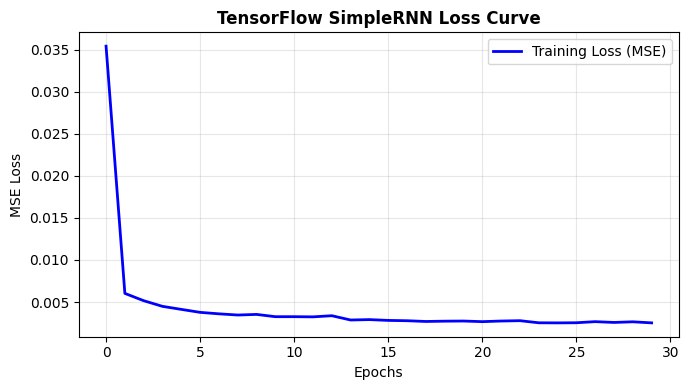

In [6]:
# ======================================================
# STEP 5: TRAINING SIMPLERNN MODEL
# ======================================================
print("--- STEP 5: TRAINING SIMPLERNN MODEL ---")

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(7, 4))
plt.plot(history_rnn.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.title("TensorFlow SimpleRNN Loss Curve", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 6: Test Evaluation & Actual vs Predicted Forecast Plot</h2>

--- STEP 6: TEST EVALUATION & FORECAST PLOT ---
TENSORFLOW SIMPLERNN FORECASTING METRICS
  • MSE:  3.2167
  • RMSE: 1.7935 °C
  • MAE:  1.3991 °C


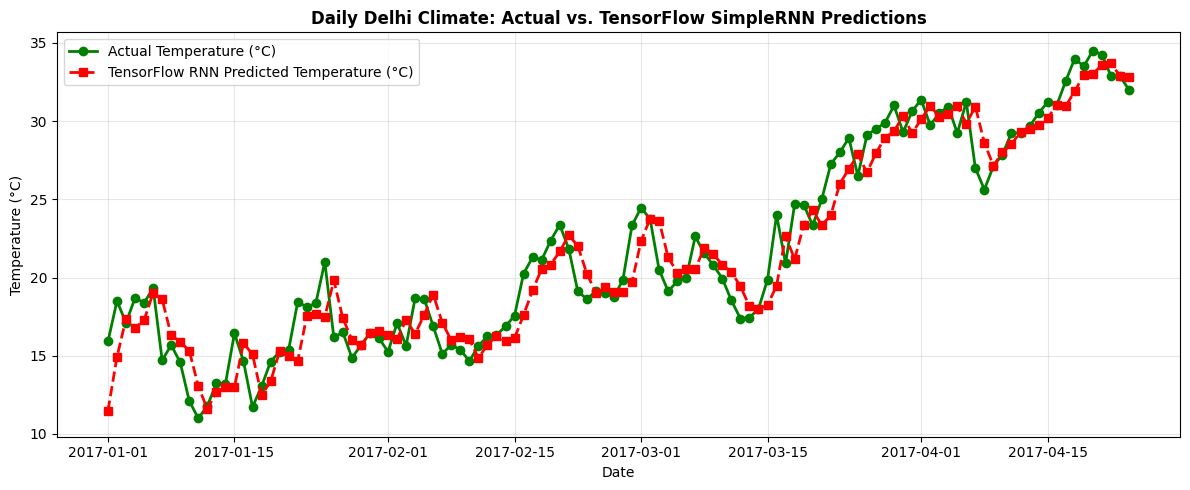

In [7]:
# ======================================================
# STEP 6: TEST EVALUATION & FORECAST PLOT
# ======================================================
print("--- STEP 6: TEST EVALUATION & FORECAST PLOT ---")

test_preds_scaled = model_rnn.predict(X_test, verbose=0)

actual_temps = scaler.inverse_transform(y_test)
predicted_temps = scaler.inverse_transform(test_preds_scaled)

test_df['date'] = pd.to_datetime(test_df['date'])

plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], actual_temps, label='Actual Temperature (°C)', color='green', linewidth=2, marker='o')
plt.plot(test_df['date'], predicted_temps, label='TensorFlow RNN Predicted Temperature (°C)', color='red', linestyle='--', linewidth=2, marker='s')
plt.title("Daily Delhi Climate: Actual vs. TensorFlow SimpleRNN Predictions", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Regression Metrics
mse = mean_squared_error(actual_temps, predicted_temps)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_temps, predicted_temps)

print("="*55)
print("TENSORFLOW SIMPLERNN FORECASTING METRICS")
print("="*55)
print(f"  • MSE:  {mse:.4f}")
print(f"  • RMSE: {rmse:.4f} °C")
print(f"  • MAE:  {mae:.4f} °C")
print("="*55)